In [ ]:
from src.utils.hdf_to_df import hdf_to_df
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

In [2]:
fname = r'/home/sroy/Documents/MMS_events/Tail_Reconnection/20170711_223000_20170711_224000.h5'

df_dict = hdf_to_df(fname)

In [10]:
start_time = datetime(2017, 7, 11, 22, 33, 30)
end_time = datetime(2017, 7, 11, 22, 34, 30)

In [3]:
B1 = df_dict['b_gse_1']

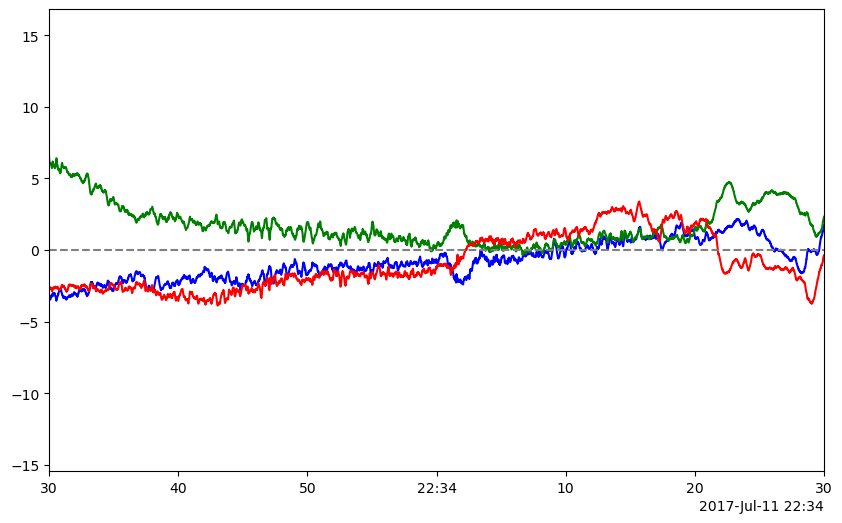

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))
plt.plot(B1['x'], 'b')
plt.plot(B1['y'], 'g')
plt.plot(B1['z'], 'r')
plt.xlim(start_time, end_time)
plt.axhline(0, ls='--', color='gray')

In [12]:
B1

,x,y,z,mag
Epoch,,,,
2017-07-11 22:30:00.005954506,-10.629918,4.323751,-1.164318,11.534539
2017-07-11 22:30:00.013759735,-10.658378,4.325306,-1.142734,11.559201
2017-07-11 22:30:00.021605192,-10.659148,4.349321,-1.163577,11.570995
2017-07-11 22:30:00.029410421,-10.643575,4.370176,-1.172030,11.565370
2017-07-11 22:30:00.037215650,-10.631002,4.381889,-1.172818,11.558315
...,...,...,...,...
2017-07-11 22:39:59.966973069,12.483734,3.796825,-1.004998,13.086998
2017-07-11 22:39:59.974818526,12.477341,3.815090,-1.036650,13.088681
2017-07-11 22:39:59.982623755,12.459140,3.791540,-1.038014,13.064586


In [ ]:
# Magnetic field variance matrix

# Start time for average
MVA_start_time = datetime(2017, 7, 11, 22, 33, 50)

# End time for average
MVA_end_time = datetime(2017, 7, 11, 22, 34, 10)

M = np.zeros((3, 3))

for i, comp1 in enumerate(['x', 'y', 'z']):
    for j, comp2 in enumerate(['x', 'y', 'z']):
        M[i, j] = (B1[comp1][MVA_start_time:MVA_end_time]*B1[comp2][MVA_start_time:MVA_end_time]).mean() - (B1[comp1][MVA_start_time:MVA_end_time].mean() * B1[comp2][MVA_start_time:MVA_end_time].mean())

eigvals, eigvecs = np.linalg.eig(M)

In [23]:
B1

,x,y,z,mag
Epoch,,,,
2017-07-11 22:30:00.005954506,-10.629918,4.323751,-1.164318,11.534539
2017-07-11 22:30:00.013759735,-10.658378,4.325306,-1.142734,11.559201
2017-07-11 22:30:00.021605192,-10.659148,4.349321,-1.163577,11.570995
2017-07-11 22:30:00.029410421,-10.643575,4.370176,-1.172030,11.565370
2017-07-11 22:30:00.037215650,-10.631002,4.381889,-1.172818,11.558315
...,...,...,...,...
2017-07-11 22:39:59.966973069,12.483734,3.796825,-1.004998,13.086998
2017-07-11 22:39:59.974818526,12.477341,3.815090,-1.036650,13.088681
2017-07-11 22:39:59.982623755,12.459140,3.791540,-1.038014,13.064586


In [25]:
(B1['x'] * B1['y']).mean()

np.float64(-4.487205623458246)